# N-pulse LMT sequence

Explicit N-pulse sequence with:
- π/2 beam splitter at +1× recoil detuning
- N π pulses to accelerate the top arm
- N π pulses to decelerate the top arm (reverse order)
- π mirror pulse at +1× recoil detuning
- N π pulses to accelerate the bottom arm
- N π pulses to decelerate the bottom arm (reverse order)
- final π/2 recombiner at +1× recoil detuning


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
import version_info as vs

In [2]:
N = 4

sequence = []

# 1) Beam splitter
sequence.append(
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label='BS pi/2',
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI / 2,
    )
)

# 2) Accelerate top arm: (+1, -3, +5, -7, ...)
top_accel = []
for i in range(N):
    k = -1 if i % 2 == 0 else +1
    detuning_mult = (-1 if i % 2 == 0 else +1) * (2 * (i+1) + 1)
    top_accel.append((k, detuning_mult))
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f'top accel {i+1}',
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        )
    )

# 3) Decelerate top arm: reverse of top acceleration
for i, (k, detuning_mult) in enumerate(reversed(top_accel), start=1):
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f'top decel {i}',
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        )
    )

# 4) Mirror pulse
sequence.append(
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label='mirror pi',
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI,
    )
)

# 5) Accelerate bottom arm: (-1, +3, -5, +7, ...), starting with k=-1
bottom_accel = []
for i in range(N):
    k = -1 if i % 2 == 0 else +1
    detuning_mult = (-1 if i % 2 == 0 else +1) * (2 * (i+1) + 1)
    bottom_accel.append((k, detuning_mult))
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f'bottom accel {i+1}',
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        )
    )

# 6) Decelerate bottom arm: reverse of bottom acceleration
for i, (k, detuning_mult) in enumerate(reversed(bottom_accel), start=1):
    sequence.append(
        seq.Pulse(
            k=k,
            detuning_hz=detuning_mult * sim.RECOIL_FREQUENCY_HZ,
            phi=0.0,
            label=f'bottom decel {i}',
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        )
    )

# 7) Final recombiner
sequence.append(
    seq.Pulse(
        k=+1,
        detuning_hz=+1 * sim.RECOIL_FREQUENCY_HZ,
        phi=0.0,
        label='BS pi/2 final',
        rabi_frequency=sim.RABI_FREQ,
        duration=sim.T_PI / 2,
    )
)


print(f'N = {N}')
print(f'Total pulses = {len(sequence)}')
for i, pulse in enumerate(sequence, start=1):
    detuning_mult = pulse.detuning_hz / sim.RECOIL_FREQUENCY_HZ
    pulse_kind = 'pi/2' if abs(pulse.duration - sim.T_PI / 2) < 1e-15 else 'pi'
    print(f'{i:02d}. {pulse.label:14s} k={pulse.k:+d}, detuning={detuning_mult:+.0f} x recoil, {pulse_kind}')

N = 4
Total pulses = 19
01. BS pi/2        k=+1, detuning=+1 x recoil, pi/2
02. top accel 1    k=-1, detuning=-3 x recoil, pi
03. top accel 2    k=+1, detuning=+5 x recoil, pi
04. top accel 3    k=-1, detuning=-7 x recoil, pi
05. top accel 4    k=+1, detuning=+9 x recoil, pi
06. top decel 1    k=+1, detuning=+9 x recoil, pi
07. top decel 2    k=-1, detuning=-7 x recoil, pi
08. top decel 3    k=+1, detuning=+5 x recoil, pi
09. top decel 4    k=-1, detuning=-3 x recoil, pi
10. mirror pi      k=+1, detuning=+1 x recoil, pi
11. bottom accel 1 k=-1, detuning=-3 x recoil, pi
12. bottom accel 2 k=+1, detuning=+5 x recoil, pi
13. bottom accel 3 k=-1, detuning=-7 x recoil, pi
14. bottom accel 4 k=+1, detuning=+9 x recoil, pi
15. bottom decel 1 k=+1, detuning=+9 x recoil, pi
16. bottom decel 2 k=-1, detuning=-7 x recoil, pi
17. bottom decel 3 k=+1, detuning=+5 x recoil, pi
18. bottom decel 4 k=-1, detuning=-3 x recoil, pi
19. BS pi/2 final  k=+1, detuning=+1 x recoil, pi/2


Clouds: 4
Clearouts: 0


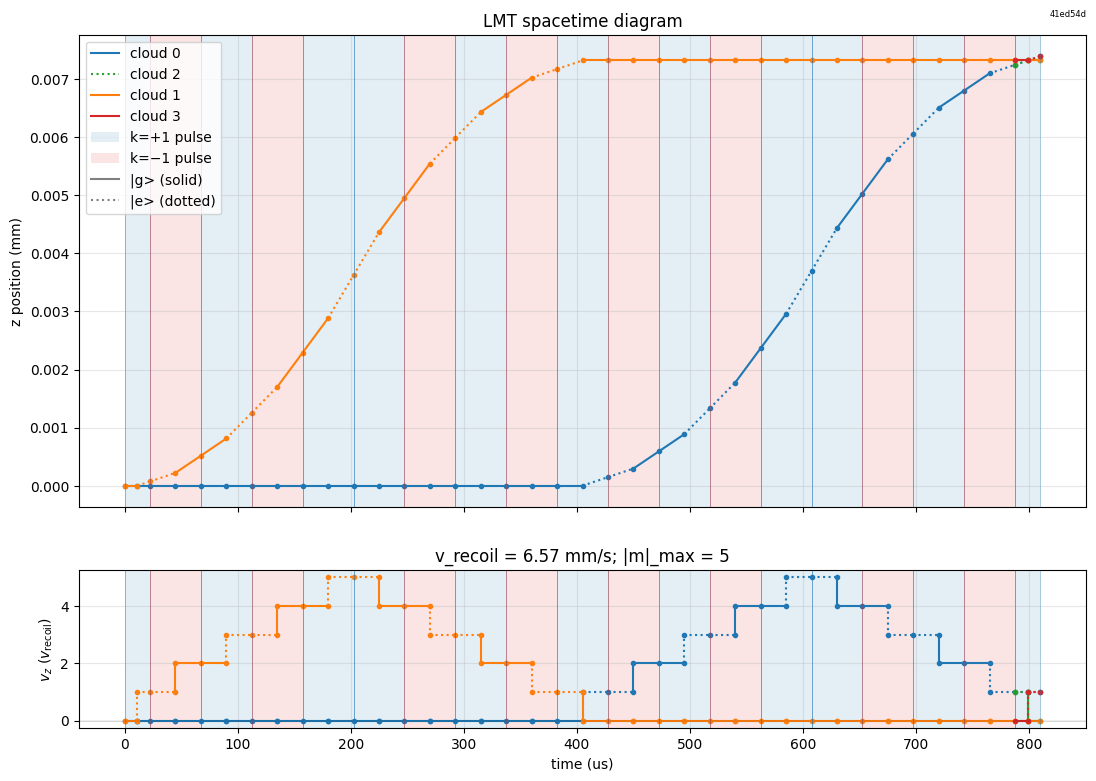

In [3]:
clouds, clearout_times = seq.compute_spacetime_trajectory(sequence, plot=True)
print(f'Clouds: {len(clouds)}')
print(f'Clearouts: {len(clearout_times)}')

vs.tag_plot(small=True);

In [ ]:
state = sim.make_atom_states(
    position_x=0.0,
    position_y=0.0,
    position_z=0.0,
    initial_velocity_z=0.0,
    c0=1.0,
    c1=0.0,
)

result = seq.run_pulse_sequence_in_lab_frame(state, pulse_sequence=sequence)
if result is None:
    raise RuntimeError('Atom was cleared out by the sequence')

state, _, _ = result
ground_prob, excited_prob = sim.calculate_ground_and_excited_probabilities(state)

print(f'Ground probability:  {ground_prob:.6f}')
print(f'Excited probability: {excited_prob:.6f}')
print(f'Excited fraction:    {excited_prob / (ground_prob + excited_prob):.6f}')